In [3]:
from google.colab import auth
auth.authenticate_user()

In [4]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn as sk
from sklearn.metrics import r2_score, mean_squared_error

# Initialise client
client = bigquery.Client()

client = bigquery.Client(project='712495287584') #insert project number

**Explaination**

*   bigquery.Client() initialises a BigQuery client using the default project from the environment.

*   bigquery.Client(project='') reinitialises the client, this time explicitly specifying the GCP project ID (XXXXXXXXX)



In [ ]:
# Write a query that counts the number of rows in the credit_table.
# count(*) is an efficient process that only needs meta data, avoids full scanning in BigQuery


query = """
SELECT COUNT(*) FROM `equifax-credit-history.anon_customer_credit.credit_table`
"""
client.query(query).to_dataframe() #Saves to Dataframe

,f0_
0,74718


Now, the question of whether to (1)process some of the data during ETL or (2)load all data in raw.

In [ ]:
# Save sample and investigate the schema

# Replace with your table ID
table_id = "equifax-credit-history.anon_customer_credit.credit_table"

# This gets table metadata
table = client.get_table(table_id)


### **Task:** Write a simple iterator to loop through table.schema and derive the following table schema attributes: i.name , i.fields, i.field_type, i.field.mode

In [ ]:
for i in table.schema:
  print(i.name , i.fields, i.field_type, i.mode)

outref10 () INTEGER NULLABLE
efx_gbflag () INTEGER NULLABLE
efx_weight () FLOAT NULLABLE
RNISF05 () INTEGER NULLABLE
RNILF05 () INTEGER NULLABLE
EIILF52 () INTEGER NULLABLE
EIILF51 () INTEGER NULLABLE
ZSC009 () STRING NULLABLE
ZSC060 () STRING NULLABLE
ZSQ009 () STRING NULLABLE
ZSQ010 () STRING NULLABLE
ZSC013 () STRING NULLABLE
ZSC004 () STRING NULLABLE
ZSC007 () STRING NULLABLE
ZSQ004 () STRING NULLABLE
ZSC006 () STRING NULLABLE
ZSQ006 () STRING NULLABLE
ZSC012 () STRING NULLABLE
ZSC008 () STRING NULLABLE
LSQ321 () STRING NULLABLE
LSQ469 () STRING NULLABLE
LSC203 () STRING NULLABLE
LSC204 () STRING NULLABLE
LSC202 () STRING NULLABLE
NSQ630 () STRING NULLABLE
OSQ451 () STRING NULLABLE
ZSC014 () STRING NULLABLE
ZSC005 () STRING NULLABLE
LSQ751 () STRING NULLABLE
TSQ438 () STRING NULLABLE
LSQ508 () STRING NULLABLE
LSQ328 () STRING NULLABLE
OSQ450 () STRING NULLABLE
BSQ412 () STRING NULLABLE
BSQ425 () STRING NULLABLE
ZAQ010 () STRING NULLABLE
BSQ164 () STRING NULLABLE
ZAQ009 () STRING NU

### **Task**: Investigate a sample of 1000 rows from the data to determine if processing can be performed with a SQL query during ETL or whether its better to load the data as is into a Dataframe and process in python.

In [ ]:
# A query that extracts a sample of 1000 from the data,
query = """
SELECT *
FROM `equifax-credit-history.anon_customer_credit.credit_table`
Limit 1000
"""

# store query results as dataframe
customers = client.query(query).to_dataframe()
customers.head()

,outref10,efx_gbflag,efx_weight,RNISF05,RNILF05,EIILF52,EIILF51,ZSC009,ZSC060,ZSQ009,...,SSQ16,CSC3,CSC40,CSC41,CSC51,LSQ072,LSC250,LSC350,LSC599,LSC251
0,1000280528,1,1.727625,450,435,191,215,4.99,-1.04,4.99,...,M,M,M,M,M,C,15,23,1650,99
1,1000576212,0,1.000000,431,431,196,234,-0.84,-0.03,-0.84,...,M,M,M,M,M,C,11,15,36900,99
2,1000793119,1,1.727625,454,439,188,234,6.42,0.38,6.42,...,M,M,M,M,M,C,17,26,4950,99
3,1000014856,0,6.252772,369,395,233,281,3.29,-1.35,3.29,...,1,M,M,M,M,C,14,21,6850,99
4,1000103116,0,1.000000,505,537,183,197,-0.5,1.15,-0.5,...,C,M,M,M,M,C,19,36,18550,99



---



### **Discuss** : Can we reliably CAST/CONVERT the data being read in? What are the Pros and Cons to this approach?

In [5]:
query = """
SELECT *
FROM `equifax-credit-history.anon_customer_credit.credit_table`
LIMIT 100000
"""

# store query results as dataframe
customers = client.query(query).to_dataframe()
customers.head()

,outref10,efx_gbflag,efx_weight,RNISF05,RNILF05,EIILF52,EIILF51,ZSC009,ZSC060,ZSQ009,...,SSQ16,CSC3,CSC40,CSC41,CSC51,LSQ072,LSC250,LSC350,LSC599,LSC251
0,1000280528,1,1.727625,450,435,191,215,4.99,-1.04,4.99,...,M,M,M,M,M,C,15,23,1650,99
1,1000576212,0,1.000000,431,431,196,234,-0.84,-0.03,-0.84,...,M,M,M,M,M,C,11,15,36900,99
2,1000793119,1,1.727625,454,439,188,234,6.42,0.38,6.42,...,M,M,M,M,M,C,17,26,4950,99
3,1000014856,0,6.252772,369,395,233,281,3.29,-1.35,3.29,...,1,M,M,M,M,C,14,21,6850,99
4,1000103116,0,1.000000,505,537,183,197,-0.5,1.15,-0.5,...,C,M,M,M,M,C,19,36,18550,99


In [ ]:
# Magic command to toggle a setting for interactive pandas tables
#%load_ext google.colab.data_table

# Turn off with this:
%unload_ext google.colab.data_table

## **Task:** View the saved dataframe's basic information with df.info() and summary stats with df.describe().

In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74718 entries, 0 to 74717
Columns: 242 entries, outref10 to LSC251
dtypes: Int64(6), float64(1), object(235)
memory usage: 138.4+ MB


In [ ]:
customers.describe()

,outref10,efx_gbflag,efx_weight,RNISF05,RNILF05,EIILF52,EIILF51
count,74718.0,74718.0,74718.000000,74718.0,74718.0,74718.0,74718.0
mean,1000399662.806927,0.040365,1.241532,504.576394,504.572513,-3993.069207,-3964.759389
std,232251.971341,0.196815,1.143923,133.922096,136.139671,4571.835006,4581.199286
min,1000000012.0,0.0,1.000000,-108.0,-108.0,-9001.0,-9001.0
25%,1000201698.75,0.0,1.000000,412.0,410.0,-9001.0,-9001.0
50%,1000403815.5,0.0,1.000000,508.0,508.0,137.0,162.0
75%,1000598563.75,0.0,1.000000,598.0,599.0,183.0,205.0
max,1000800682.0,1.0,32.727273,1027.0,1027.0,319.0,319.0


## **Task:** Create a visualisaton of the KPI 'efx_gbflag'

<Axes: xlabel='RNISF05', ylabel='efx_gbflag'>

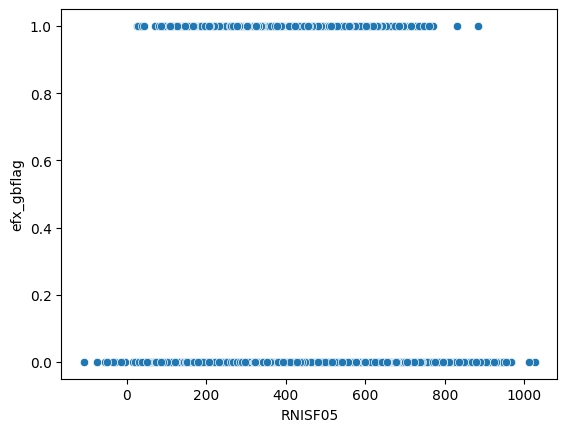

In [6]:
import seaborn as sns
sns.scatterplot(data=customers, x="RNISF05", y="efx_gbflag")

<Axes: xlabel='efx_gbflag', ylabel='Count'>

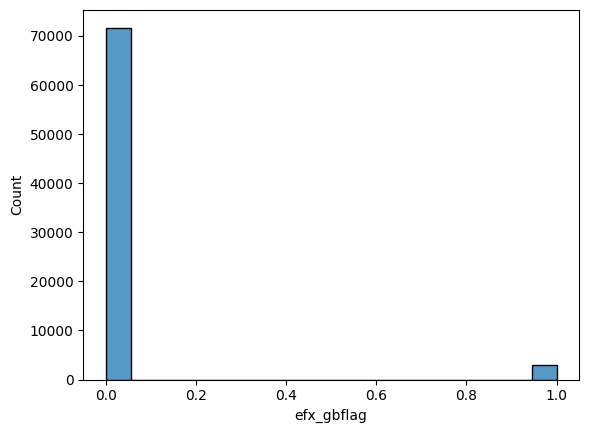

In [11]:

sns.histplot(customers,x="efx_gbflag")

## **Task:** Connect to the "clean headers" table in GCP and load it into this python environment. Perform the same checks on the appropriateness of the data as a dataframe and its relevance to the customer data

In [12]:
query = """
SELECT COUNT(*) FROM `equifax-credit-history.customer_table_descriptions.clean_headers`
"""
client.query(query).to_dataframe().rename(columns = {'string_field_0':'Code','string_field_1':'Description'}).to_csv('clean_headers.csv', index=False) #Saves to Dataframe

## **Task:** change column names from 'string_field_0' to 'Code' and 'string_field_1' to 'Description'

Before processing, it would be efficient to cache or save your data locally to work on it in python without incurring costs from repeated queries.Write your data to a csv file, cached in this cloud environment. Can also download the file directly and save it locally.

## **Task:** When satisfied, cache / save your dataframes locally, using df.to_csv('path/file.csv', index=True)

In [19]:
query = """
SELECT * FROM `equifax-credit-history.anon_customer_credit.credit_table`
"""
client.query(query).to_dataframe().to_csv('/content/drive/MyDrive/Colab Notebooks/credit_table.csv', index=False) #Saves to Dataframe

query = """
SELECT * FROM `equifax-credit-history.customer_table_descriptions.clean_headers`
"""
client.query(query).to_dataframe().rename(columns = {'string_field_0':'Code','string_field_1':'Description'}).to_csv('/content/drive/MyDrive/Colab Notebooks/clean_headers.csv', index=False) #Saves to Dataframe

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Alternatively - UPLOAD Dataframes TO GCP -
NOTE: This requires billing account

2 Options
1. Big Query client, load table form dataframe
2. Big Frames package's to_gbq() streamlines process.

In [ ]:
#### OPTION 1 -- UPLOAD DF TO GCP ####

from google.cloud import bigquery

# Init BigQuery client
client = bigquery.Client()

# Define destination table
table_id = "your-project.your_dataset.your_table"

# Upload DataFrame
job = client.load_table_from_dataframe(df, table_id)
job.result()  # Wait for completion

print(f"Uploaded {job.output_rows} rows to {table_id}")

In [ ]:
#### OPTION 2 -- UPLOAD DF to GCP ####

import bigframes.pandas as bpd

bdf = bpd.from_pandas(df)
bdf.to_gbq("your-project.your_dataset.your_table", if_exists="replace")